# Desafio 4 — Sibila
### Residência Tecnológica em Análise de Dados e Inteligência Artificial

**Mentor responsável:** Nicola Pedulla

**Eixo temático:** Segmentação de risco patrimonial

---

## 1. Business Understanding

### 1.1 Contexto de negócio

Uma seguradora atuante no segmento empresarial precisa decidir, **no momento imediatamente anterior à emissão de uma apólice**, se aquele contrato representa um risco elevado. O foco de negócio deste eixo não é qual evento específico pode ocorrer (vendaval, danos elétricos, roubo/furto), mas sim antecipar **se vai haver sinistro ou não** (`ALVO`: 1 = houve sinistro, 0 = não houve), para que a seguradora possa agir sobre o risco antes de assumi-lo, reduzindo despesas com indenizações e otimizando o ganho operacional.

### 1.2 Hipóteses de mercado

- **Porte e natureza jurídica** devem influenciar o risco pois mpresas maiores costumam ter mais controles de segurança patrimonial (câmeras, seguranças, sistemas contra incêndio) que empresas pequenas/MEI.
- **Contexto geográfico** (concentração de determinados estabelecimentos ao redor, distância de pontos de referência) deve se relacionar com exposição a roubo/furto e a outros riscos.
- **Histórico de mercado** (abertura/fechamento de empresas similares na região, taxa de sobrevivência do setor) pode servir como *proxy* de estabilidade econômica local, que por sua vez se relaciona com criminalidade e risco operacional.
- **Histórico de reclamações e processos judiciais** pode capturar informalmente o "perfil de risco" do CNPJ, independente do imóvel em si.

### 1.3 Plano do experimento

Este notebook segue as 5 primeiras etapas do CRISP-DM (Business Understanding → Evaluation), deixando a etapa de **Deployment fora do escopo**, conforme orientação da atividade.

| Etapa | O que será feito |
|---|---|
| Business Understanding | Este bloco |
| Data Understanding | Nulos, outliers, poder de predição, e principalmente **consistência temporal** (Data Drift x Concept Drift) |
| Data Preparation | Definição do split treino/teste, redução de variáveis, tratamento de nulos, encoding, feature engineering |
| Modelling | Classificação supervisionada (`RandomForestClassifier`), com busca de hiperparâmetros, respeitando a separação treino/teste |
| Evaluation | KS (treino e teste), curva ROC, gráfico de decil, ponto de corte para recusa de apólice, estabilidade do score no tempo |

## 2. Setup e carga dos dados


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, KBinsDiscretizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42

In [ ]:
try:
    import google.colab
    EM_COLAB = True
except ImportError:
    EM_COLAB = False

if EM_COLAB:
    from google.colab import files
    print('Faça upload do arquivo BASE_EMPRESAS_SINISTRO.csv:')
    arquivos_enviados = files.upload()
    caminho_arquivo = list(arquivos_enviados.keys())[0]
else:
    caminho_arquivo = 'BASE_EMPRESAS_SINISTRO.csv'

print(f'Arquivo utilizado: {caminho_arquivo}')

Faça upload do arquivo BASE_EMPRESAS_SINISTRO.csv:


Saving BASE_EMPRESAS_SINISTRO.csv to BASE_EMPRESAS_SINISTRO.csv
Arquivo utilizado: BASE_EMPRESAS_SINISTRO.csv


In [ ]:
df = pd.read_csv(caminho_arquivo, sep='\t')
df['ANO_MES'] = df['ANO_MES'].astype(int)
df['ANO'] = df['ANO_MES'].astype(str).str[:4].astype(int)

print(f'Linhas: {df.shape[0]:,}'.replace(',', '.'))
print(f'Colunas: {df.shape[1]}')
df.head(3)

Linhas: 32.868
Colunas: 103


,SECAO_CNAE,CATEGORIA_NATUREZA_JURIDICA,PORTE,QTD_FILIAIS_ATIVAS,COMPETICAO_MERCADO_ESTADUAL,QTD_ABERTURAS_NACIONAL_5_ANOS,QTD_ABERTURAS_ESTADUAL_5_ANOS,QTD_ABERTURAS_GEORREFERENCIADO_5_ANOS,QTD_FECHAMENTOS_NACIONAL_5_ANOS,QTD_FECHAMENTOS_ESTADUAL_5_ANOS,QTD_FECHAMENTOS_GEORREFERENCIADO_5_ANOS,RAZAO_SITUACAO_MERCADO_NACIONAL_5_ANOS,RAZAO_SITUACAO_MERCADO_ESTADUAL_5_ANOS,RAZAO_SITUACAO_MERCADO_GEORREFERENCIADO_5_ANOS,TAXA_SOBREVIVENCIA_MERCADO_5_ANOS,TAXA_SOBREVIVENCIA_MERCADO_10_ANOS,PORTE_FATURAMENTO_PRESUMIDO,QTD_COLABORADORES,CONCENTRACAO_SOCIETARIA,RISCO_LIDERANCA,QTD_RECLAMACOES_TOTAL,QTD_RECLAMACOES_NAO_ATENDIDAS_TOTAL,QTD_PROCESSOS_JUDICIAIS_REQUERIDO,QTD_PROCESSOS_JUDICIAIS_REQUERENTE,CONCENTRACAO_ACADEMIAS,CONCENTRACAO_AEROPORTOS,CONCENTRACAO_ALUGUEL_CARROS,CONCENTRACAO_AREA_RISCO,CONCENTRACAO_BANCOS,CONCENTRACAO_BARES,CONCENTRACAO_BEBIDAS,CONCENTRACAO_BOMBEIRO,CONCENTRACAO_CAIXA_ELETRONICO,CONCENTRACAO_CASA_NOTURNA,CONCENTRACAO_CEMITERIO,CONCENTRACAO_CINEMAS,CONCENTRACAO_CONCESSIONARIA,CONCENTRACAO_CORREIOS,CONCENTRACAO_CORRETOR_SEGUROS,CONCENTRACAO_ESCOLAS,CONCENTRACAO_ESTACAO_ONIBUS,CONCENTRACAO_ESTACIONAMENTOS,CONCENTRACAO_AGLOMERADO_SUBNORMAL,CONCENTRACAO_FUNERARIA,CONCENTRACAO_HOSPITAL,CONCENTRACAO_HOTEL,CONCENTRACAO_IGREJA,CONCENTRACAO_LAVA_RAPIDO,CONCENTRACAO_METRO,CONCENTRACAO_OFICINAS,CONCENTRACAO_PARQUE,CONCENTRACAO_PARQUES_DIVERSAO,CONCENTRACAO_POLICIA,CONCENTRACAO_PONTO_TAXI,CONCENTRACAO_POSTO_GASOLINA,CONCENTRACAO_PREFEITURA,CONCENTRACAO_SHOPPING,CONCENTRACAO_SUPERMERCADO,CONCENTRACAO_TREM,CONCENTRACAO_UNIVERSIDADE,DISTANCIA_ALUGUEL_CARROS,DISTANCIA_BANCO,DISTANCIA_CONCESSIONARIA,DISTANCIA_CORRETOR_SEGUROS,DISTANCIA_ACADEMIAS,DISTANCIA_AEROPORTOS,DISTANCIA_BARES,DISTANCIA_LOJA_BEBIDAS,DISTANCIA_BOMBEIRO,DISTANCIA_CAIXA_ELETRONICO,DISTANCIA_CASA_NOTURNA,DISTANCIA_CEMITERIO,DISTANCIA_CINEMAS,DISTANCIA_CORREIOS,DISTANCIA_ESCOLAS,DISTANCIA_ESTACAO_ONIBUS,DISTANCIA_AGLOMERADO_SUBNORMAL,DISTANCIA_FRONTEIRA_ESTADUAL,DISTANCIA_FRONTEIRA_INTERNACIONAL,DISTANCIA_FRONTEIRA_MARITIMA,DISTANCIA_FUNERARIA,DISTANCIA_HOSPITAL,DISTANCIA_HOTEL,DISTANCIA_IGREJA,DISTANCIA_LAVA_RAPIDO,DISTANCIA_METRO,DISTANCIA_OFICINAS,DISTANCIA_PARQUE,DISTANCIA_PARQUES_DIVERSAO,DISTANCIA_POLICIA,DISTANCIA_POSTO_GASOLINA,DISTANCIA_PREFEITURA,DISTANCIA_SHOPPING,DISTANCIA_SUPERMERCADO,DISTANCIA_TREM,DISTANCIA_ESTACIONAMENTOS,DISTANCIA_PONTO_TAXI,DISTANCIA_UNIVERSIDADE,DISTANCIA_AREA_RISCO,CNPJ,ANO_MES,ALVO,ANO
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8589937055,201907,1.0,2019
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3338,201908,1.0,2019
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8589935709,202002,1.0,2020


**Sobre a chave `CNPJ`:** confirmado com o mentor que os valores são **anonimizados**, não um CNPJ real formatado/censurado. Portanto ele serve apenas como identificador de empresa (para checar repetição entre períodos), nunca como variável explicativa.

## 3. Data Understanding

### 3.1 Estrutura geral e grupos de variáveis

A base tem 102 colunas. Organizamos em grupos, porque cada um vai levar tratamento diferente mais adiante:

In [ ]:
id_cols = ['CNPJ', 'ANO_MES', 'ANO']
target_col = 'ALVO'

num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols = [c for c in num_cols if c not in id_cols + [target_col]]

cat_cols = [c for c in df.columns if c not in num_cols + id_cols + [target_col]]
concentracao_cols = [c for c in cat_cols if c.startswith('CONCENTRACAO')]
distancia_cols = [c for c in cat_cols if c.startswith('DISTANCIA')]
nominal_cols = [c for c in cat_cols if c not in concentracao_cols + distancia_cols]

print(f'Numéricas: {len(num_cols)}')
print(f'Ordinais CONCENTRACAO_*: {len(concentracao_cols)}')
print(f'Ordinais DISTANCIA_*: {len(distancia_cols)}')
print(f'Nominais (cadastrais): {len(nominal_cols)} -> {nominal_cols}')
print(f'Total: {len(num_cols)+len(concentracao_cols)+len(distancia_cols)+len(nominal_cols)} (+ id/alvo)')

Numéricas: 20
Ordinais CONCENTRACAO_*: 36
Ordinais DISTANCIA_*: 39
Nominais (cadastrais): 4 -> ['SECAO_CNAE', 'CATEGORIA_NATUREZA_JURIDICA', 'PORTE', 'PORTE_FATURAMENTO_PRESUMIDO']
Total: 99 (+ id/alvo)


### 3.2 Taxa de dados ausentes

99 colunas com algum nulo, de 103.


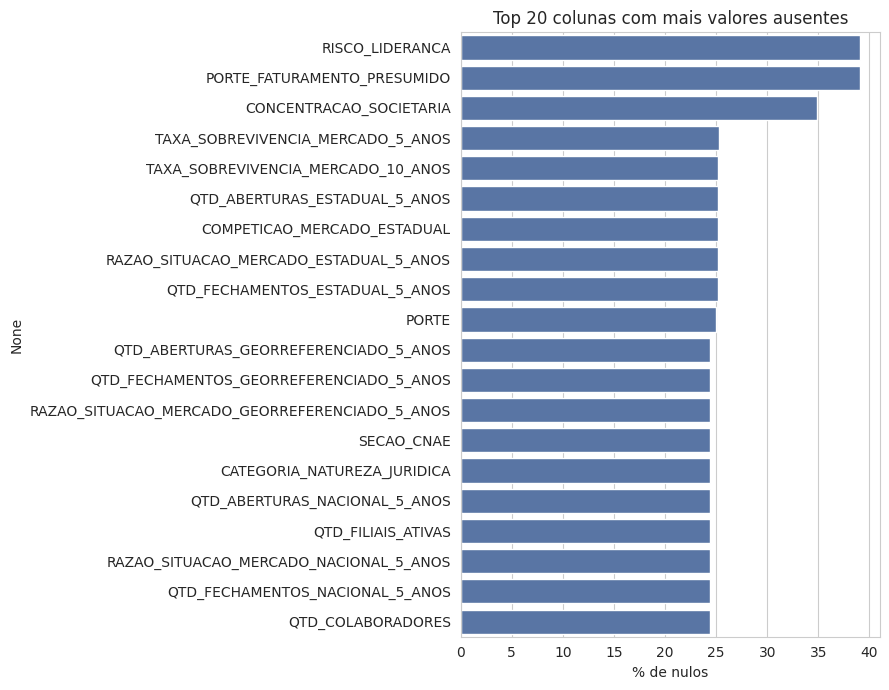

In [ ]:
nulos_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
nulos_pct = nulos_pct[nulos_pct > 0]
print(f'{len(nulos_pct)} colunas com algum nulo, de {df.shape[1]}.')

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=nulos_pct.head(20).values, y=nulos_pct.head(20).index, ax=ax, color='#4C72B0')
ax.set_xlabel('% de nulos')
ax.set_title('Top 20 colunas com mais valores ausentes')
plt.tight_layout()
plt.show()

**Decisão de EDA #1:** os nulos se concentram num grupo específico de variáveis (indicadores de mercado/porte), entre ~24% e ~39%. Como sugestão do mentor: numéricas serão imputadas pela **média**, e categóricas ganham uma **categoria própria `ISMISSING`** em vez de serem descartadas, preservando o sinal de "ausência de informação" como algo potencialmente informativo, não como ruído a esconder.

### 3.3 Outliers

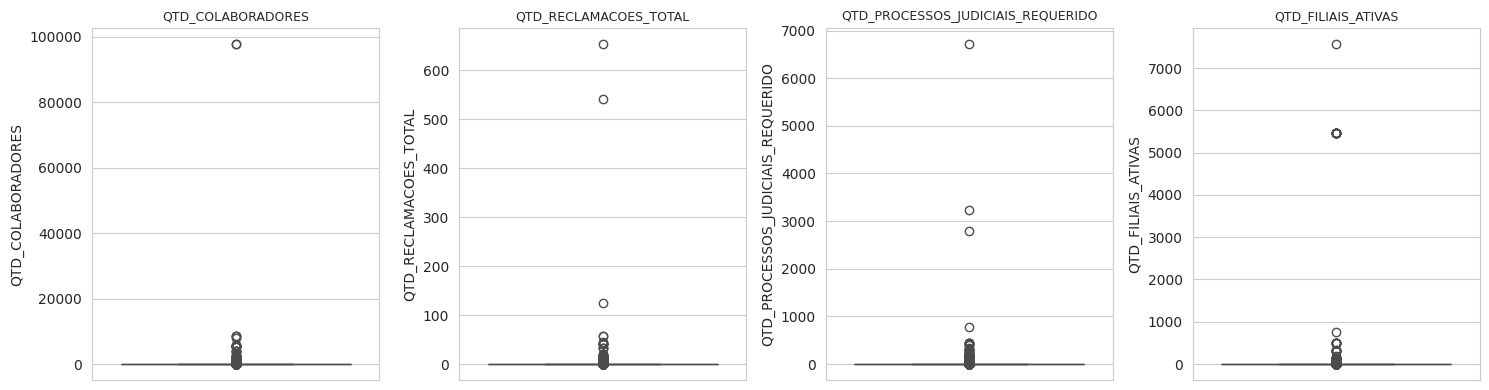

In [ ]:
cols_outlier = ['QTD_COLABORADORES', 'QTD_RECLAMACOES_TOTAL', 'QTD_PROCESSOS_JUDICIAIS_REQUERIDO', 'QTD_FILIAIS_ATIVAS']

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, cols_outlier):
    sns.boxplot(y=df[col], ax=ax, color='#4C72B0')
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

**Decisão de EDA #2:** existem outliers claros em variáveis de contagem (reclamações, processos), mas optamos por **não removê-los**. O modelo escolhido (Random Forest, baseado em árvores) é naturalmente robusto a outliers. Remover essas linhas jogaria fora empresas atípicas que são justamente informativas para o problema de risco.

### 3.4 Poder de predição (relação com o alvo)

Com 102 variáveis, faz sentido medir de forma simples o quanto cada uma se relaciona com `ALVO`, e usar isso mais adiante para reduzir a base de variáveis (Seção 4.2). Para numéricas, usamos correlação de Pearson; para as ordinais (`CONCENTRACAO_*`/`DISTANCIA_*`), medimos a amplitude da taxa de sinistro entre a categoria de maior e menor risco usando a mesma lógica.

P.S: O ranking calculado aqui usa a base inteira (2019-2021) só para fins de **entendimento exploratório**. A **seleção oficial de variáveis**, feita na Seção 4.2, recalcula essa mesma métrica usando **apenas o treino** (Cenário B), para não deixar a escolha de features "espiar" dado de teste ou o período de 2021 que decidimos excluir.

In [ ]:
corr_num = df[num_cols + [target_col]].corr(numeric_only=True)[target_col].drop(target_col).abs().sort_values(ascending=False)

def amplitude_taxa(col):
    tab = df.groupby(col)[target_col].agg(['mean', 'count'])
    tab = tab[tab['count'] >= 30]
    if len(tab) < 2:
        return 0
    return tab['mean'].max() - tab['mean'].min()

amplitude_ordinais = pd.Series({c: amplitude_taxa(c) for c in concentracao_cols + distancia_cols}).sort_values(ascending=False)
amplitude_nominais = pd.Series({c: amplitude_taxa(c) for c in nominal_cols}).sort_values(ascending=False)

print('Top 10 numéricas por |correlação| com ALVO:')
print(corr_num.head(10).round(3))
print()
print('Top 10 ordinais por amplitude de taxa de sinistro:')
print(amplitude_ordinais.head(10).round(3))

Top 10 numéricas por |correlação| com ALVO:
QTD_ABERTURAS_ESTADUAL_5_ANOS             0.034
QTD_FECHAMENTOS_ESTADUAL_5_ANOS           0.029
COMPETICAO_MERCADO_ESTADUAL               0.028
CONCENTRACAO_SOCIETARIA                   0.018
RAZAO_SITUACAO_MERCADO_NACIONAL_5_ANOS    0.017
QTD_FECHAMENTOS_NACIONAL_5_ANOS           0.016
TAXA_SOBREVIVENCIA_MERCADO_10_ANOS        0.015
RAZAO_SITUACAO_MERCADO_ESTADUAL_5_ANOS    0.015
QTD_ABERTURAS_NACIONAL_5_ANOS             0.015
QTD_FILIAIS_ATIVAS                        0.009
Name: ALVO, dtype: float64

Top 10 ordinais por amplitude de taxa de sinistro:
DISTANCIA_CINEMAS                    0.237
DISTANCIA_TREM                       0.230
DISTANCIA_PONTO_TAXI                 0.216
DISTANCIA_METRO                      0.210
DISTANCIA_AEROPORTOS                 0.201
DISTANCIA_AGLOMERADO_SUBNORMAL       0.193
CONCENTRACAO_AGLOMERADO_SUBNORMAL    0.191
DISTANCIA_SHOPPING                   0.189
CONCENTRACAO_POLICIA                 0.187
CONCENTRAC

### 3.5 Consistência temporal: Data Drift x Concept Drift

- **Data Drift** — a *distribuição das variáveis explicativas* (X) mudou entre os períodos?
- **Concept Drift** — a *relação entre as variáveis e o alvo* (P(Y\|X)) mudou entre os períodos?

#### 3.5.1 Taxa de sinistro por safra (ANO_MES) — visão geral

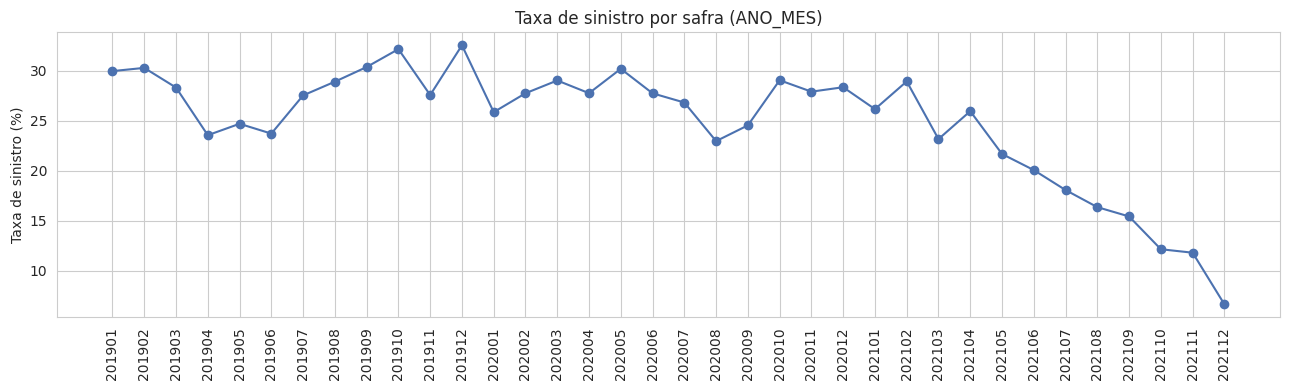

In [ ]:
taxa_safra = df.groupby('ANO_MES')[target_col].mean() * 100

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(taxa_safra.index.astype(str), taxa_safra.values, marker='o', color='#4C72B0')
ax.set_xticklabels(taxa_safra.index.astype(str), rotation=90)
ax.set_ylabel('Taxa de sinistro (%)')
ax.set_title('Taxa de sinistro por safra (ANO_MES)')
plt.tight_layout()
plt.show()

A taxa fica estável (oscilando entre ~20% e ~32%) até meados de 2021, e então cai de forma acentuada, chegando a 6,6% em dezembro/2021. Esse formato estável e depois um degrau acelerado só no fim da série é mais compatível com **dado ainda não maturado** (sinistros recentes que ainda não foram totalmente registrados na base) do que com uma mudança real e gradual de risco.

#### 3.5.2 Data Drift — a composição da carteira mudou?

Comparamos a distribuição de algumas variáveis entre 2019 e 2021, para ver se a "população" de empresas mudou. Olhamos duas: `PORTE` (cadastral, fácil de interpretar) e `DISTANCIA_CINEMAS` (a variável com maior amplitude de taxa de sinistro na Seção 3.4). Vale checar se justamente a variável mais forte do modelo está estável no tempo.

In [ ]:
comparacao_porte = pd.crosstab(df['ANO'], df['PORTE'], normalize='index') * 100
comparacao_porte.round(1)

PORTE,GRANDE,MEDIA,MEI,MICRO,PEQUENA
ANO,,,,,
2019,2.5,8.6,4.7,53.7,30.5
2020,2.0,7.2,5.7,54.4,30.8
2021,1.4,6.3,6.5,56.2,29.6


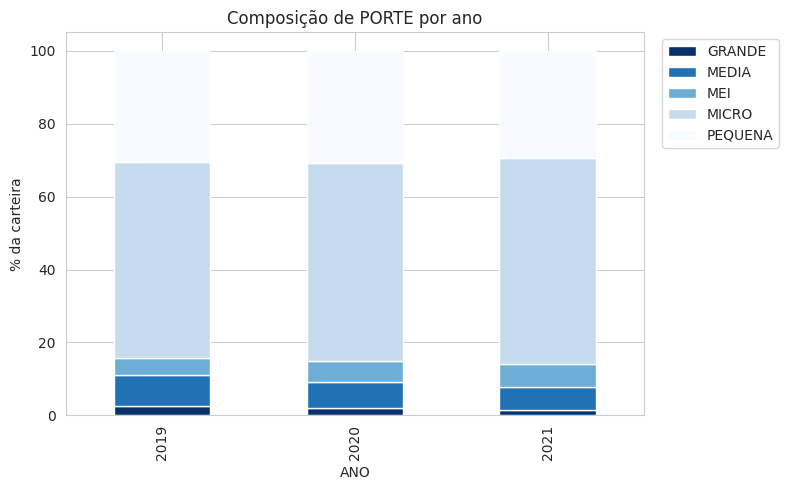

In [ ]:
comparacao_porte.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Blues_r')
plt.ylabel('% da carteira')
plt.title('Composição de PORTE por ano')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
comparacao_distancia_cinemas = pd.crosstab(df['ANO'], df['DISTANCIA_CINEMAS'], normalize='index') * 100
comparacao_distancia_cinemas = comparacao_distancia_cinemas[['MUITO PROXIMO', 'PROXIMO', 'MEDIO', 'LONGE', 'MUITO LONGE']]
comparacao_distancia_cinemas.round(1)

DISTANCIA_CINEMAS,MUITO PROXIMO,PROXIMO,MEDIO,LONGE,MUITO LONGE
ANO,,,,,
2019,1.2,46.1,20.4,18.9,13.3
2020,1.1,45.7,20.2,20.1,12.9
2021,1.3,46.7,20.6,18.7,12.7


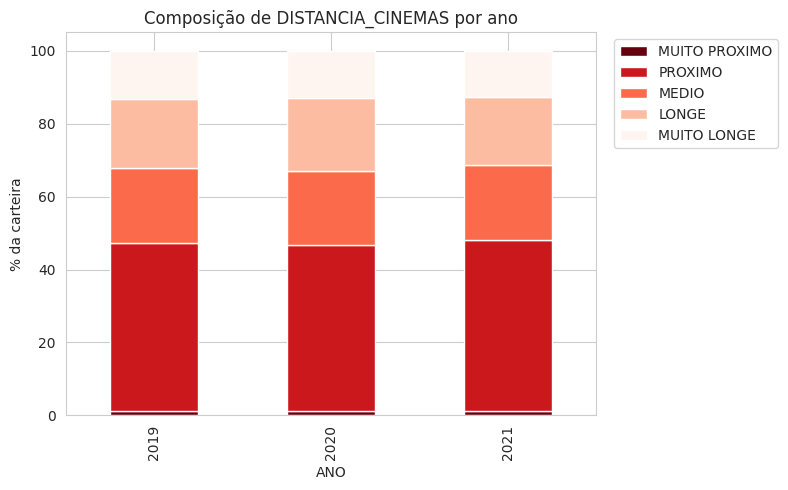

In [ ]:
comparacao_distancia_cinemas.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Reds_r')
plt.ylabel('% da carteira')
plt.title('Composição de DISTANCIA_CINEMAS por ano')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Leitura:** existe uma leve mudança de mix em `PORTE` (um pouco mais de MEI/MICRO e menos GRANDE em 2021), mas é pequena demais para explicar uma queda de taxa de sinistro de ~28% para ~19%. `DISTANCIA_CINEMAS`: a variável mais forte do ranking de poder de predição se mantém praticamente estável entre os anos. Ou seja: **Data Drift existe, mas é discreto, inclusive na variável que mais importa para o modelo.**

#### 3.5.3 Concept Drift — a relação entre variável e alvo mudou?

Acompanhamos a taxa de sinistro por categoria de `PORTE` **e** de `DISTANCIA_CINEMAS` ao longo das safras. Se as linhas mantiverem a mesma ordem relativa entre si ao longo do tempo, é sinal de que a relação entre a variável e o risco não mudou, mesmo que o nível geral tenha caído.

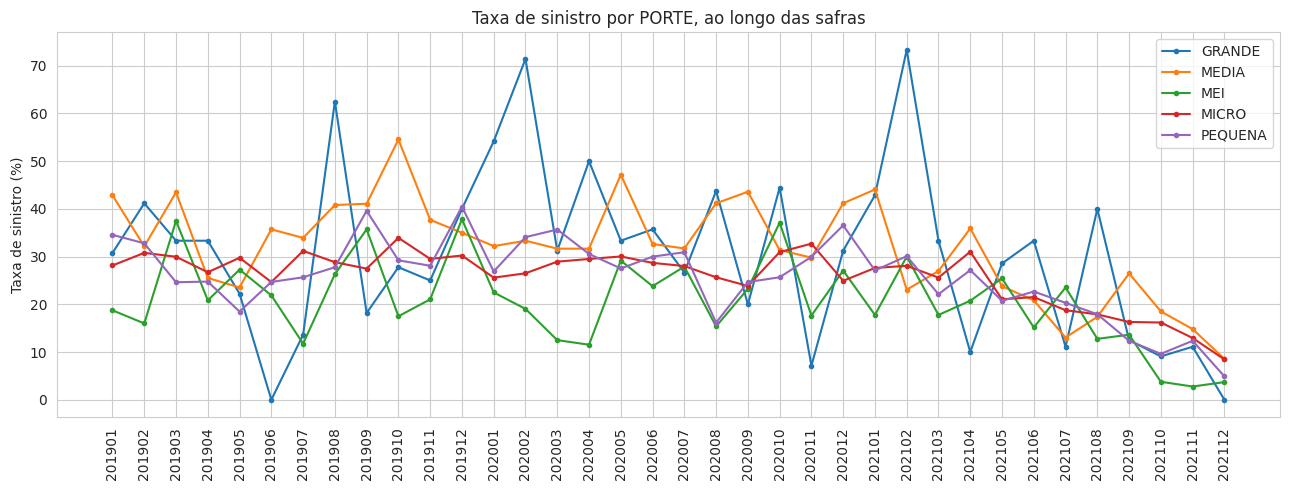

In [ ]:
taxa_por_porte_safra = df.groupby(['ANO_MES', 'PORTE'])[target_col].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(13, 5))
for porte in taxa_por_porte_safra.columns:
    ax.plot(taxa_por_porte_safra.index.astype(str), taxa_por_porte_safra[porte], marker='.', label=porte)
ax.set_xticklabels(taxa_por_porte_safra.index.astype(str), rotation=90)
ax.set_ylabel('Taxa de sinistro (%)')
ax.set_title('Taxa de sinistro por PORTE, ao longo das safras')
ax.legend()
plt.tight_layout()
plt.show()

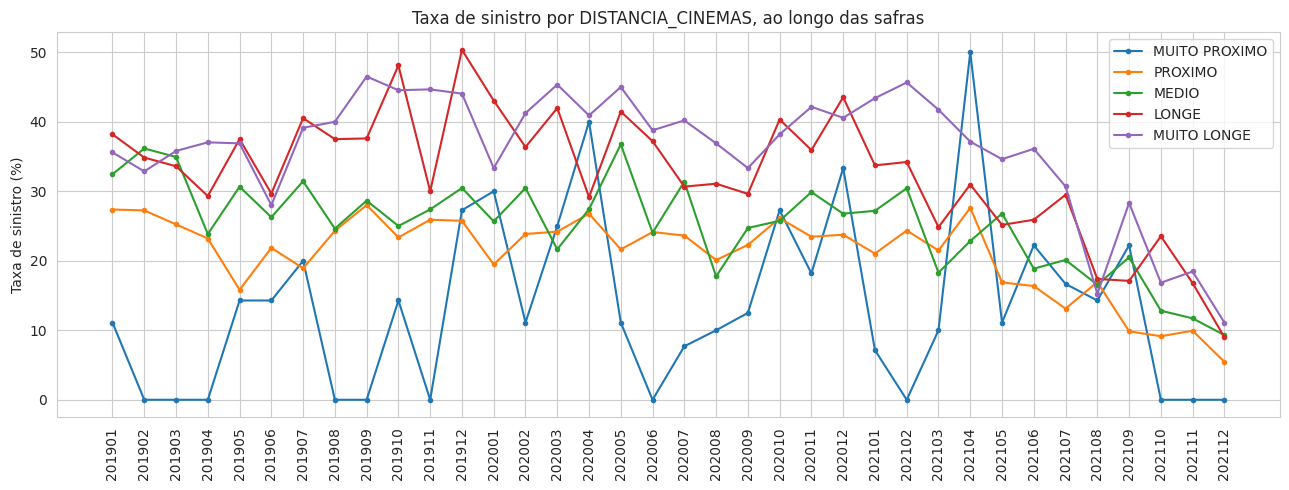

In [ ]:
taxa_por_distancia_safra = df.groupby(['ANO_MES', 'DISTANCIA_CINEMAS'])[target_col].mean().unstack() * 100
taxa_por_distancia_safra = taxa_por_distancia_safra[['MUITO PROXIMO', 'PROXIMO', 'MEDIO', 'LONGE', 'MUITO LONGE']]

fig, ax = plt.subplots(figsize=(13, 5))
for categoria in taxa_por_distancia_safra.columns:
    ax.plot(taxa_por_distancia_safra.index.astype(str), taxa_por_distancia_safra[categoria], marker='.', label=categoria)
ax.set_xticklabels(taxa_por_distancia_safra.index.astype(str), rotation=90)
ax.set_ylabel('Taxa de sinistro (%)')
ax.set_title('Taxa de sinistro por DISTANCIA_CINEMAS, ao longo das safras')
ax.legend()
plt.tight_layout()
plt.show()

**Leitura:** em ambas as variáveis, todas as categorias caem juntas no mesmo período (fim de 2021). Se fosse uma mudança real de comportamento de risco em um segmento específico, esperaríamos ver as linhas se cruzarem ou se distanciarem, não caírem todas em bloco. E o mais importante: isso vale tanto para `PORTE` (variável fraca) quanto para `DISTANCIA_CINEMAS` (a variável mais forte do ranking), reforçando que o problema é de **maturação do dado (rótulo)**, não de mudança de relação entre variável e risco, mesmo nas variáveis que o modelo mais usa.

**Conclusão da Seção 3.5:** decidimos **excluir os dados de 2021** do treino e do teste oficiais deste projeto, por não estarem maturados. 2021 é mantido apenas como leitura ilustrativa de estabilidade do score (Seção 6.6), fora da avaliação principal.

## 4. Data Preparation

### 4.1 Definição do split treino/teste

- **Cenário A (não usado oficialmente):** treino = 2019-2020, teste = 2021 inteiro
- **Cenário B (escolhido):** treino = jan/2019 a set/2020, teste = out/2020 a dez/2020 (últimos 3 meses do período maturado, respeitando a ordem cronológica — simula a situação de produção)

O Cenário B é a divisão oficial usada em Modelling e Evaluation. O Cenário A é retomado só na Seção 6.5, para comparação, mostrando o que aconteceria se não tivéssemos filtrado o período não maturado.

In [ ]:
df_modelo = df.dropna(subset=[target_col]).copy()

# --- Cenário B (oficial) ---
treino_b = df_modelo[(df_modelo['ANO_MES'] >= 201901) & (df_modelo['ANO_MES'] <= 202009)].sort_values('ANO_MES').reset_index(drop=True)
teste_b = df_modelo[(df_modelo['ANO_MES'] >= 202010) & (df_modelo['ANO_MES'] <= 202012)].sort_values('ANO_MES').reset_index(drop=True)

# --- Cenário A (comparação) ---
treino_a = df_modelo[df_modelo['ANO'] <= 2020].sort_values('ANO_MES').reset_index(drop=True)
teste_a = df_modelo[df_modelo['ANO'] == 2021].sort_values('ANO_MES').reset_index(drop=True)

print('Cenário B (oficial):')
print(f'  Treino: {len(treino_b):,} linhas | Taxa sinistro: {treino_b[target_col].mean()*100:.1f}%'.replace(',', '.'))
print(f'  Teste:  {len(teste_b):,} linhas | Taxa sinistro: {teste_b[target_col].mean()*100:.1f}%'.replace(',', '.'))
print()
print('Cenário A (comparação):')
print(f'  Treino: {len(treino_a):,} linhas | Taxa sinistro: {treino_a[target_col].mean()*100:.1f}%'.replace(',', '.'))
print(f'  Teste:  {len(teste_a):,} linhas | Taxa sinistro: {teste_a[target_col].mean()*100:.1f}%'.replace(',', '.'))

Cenário B (oficial):
  Treino: 18.375 linhas | Taxa sinistro: 27.7%
  Teste:  3.113 linhas | Taxa sinistro: 28.5%

Cenário A (comparação):
  Treino: 21.488 linhas | Taxa sinistro: 27.8%
  Teste:  11.380 linhas | Taxa sinistro: 19.3%


No Cenário B a taxa de treino (27,7%) e teste (28,5%) ficam próximas, coerente com um período maturado e estável. No Cenário A, a diferença é grande (27,8% treino vs. 19,3% teste), exatamente o sintoma que motivou excluir 2021.

**Checagem de vazamento entre treino e teste (Cenário B):** além do corte cronológico, vale confirmar quanto o mesmo CNPJ aparece nos dois períodos. Se a sobreposição for grande, o teste deixa de ser uma medida limpa de generalização, porque o modelo já teria "visto" parte daquelas empresas no treino.

In [ ]:
cnpj_treino_b = set(treino_b['CNPJ'])
cnpj_teste_b = set(teste_b['CNPJ'])
sobreposicao_b = cnpj_treino_b & cnpj_teste_b

print(f'CNPJs distintos no treino: {len(cnpj_treino_b):,}'.replace(',', '.'))
print(f'CNPJs distintos no teste:  {len(cnpj_teste_b):,}'.replace(',', '.'))
print(f'CNPJs presentes nos dois:  {len(sobreposicao_b):,} ({len(sobreposicao_b)/len(cnpj_teste_b)*100:.1f}% do teste)'.replace(',', '.'))

CNPJs distintos no treino: 16.936
CNPJs distintos no teste:  3.059
CNPJs presentes nos dois:  357 (11.7% do teste)


**Leitura:** com um split temporal contínuo (sem buraco entre treino e teste), é esperado que uma fração das empresas do teste também apareça no treino. É o cenário real de produção, onde clientes já existentes continuam sendo avaliados. O que importaria como sinal de alerta seria uma sobreposição muito próxima de 100% (o teste seria basicamente "repetição" do treino), que não é o caso aqui.

### 4.2 Redução de variáveis (102 → um subconjunto mais enxuto)

Recalculamos o poder de predição (Seção 3.4) usando **apenas o treino do Cenário B**, para a seleção de variáveis não usar nenhuma informação do teste nem do período de 2021 já excluído. Aplicamos o **mesmo critério de corte a todos os grupos**, não só às ordinais: mantemos as 20 melhores `CONCENTRACAO_*`, as 20 melhores `DISTANCIA_*`, e as **15 melhores numéricas** (de 20). As nominais permanecem inteiras por já serem poucas (4 colunas).

In [ ]:
def amplitude_taxa_treino(col):
    tab = treino_b.groupby(col)[target_col].agg(['mean', 'count'])
    tab = tab[tab['count'] >= 30]
    if len(tab) < 2:
        return 0
    return tab['mean'].max() - tab['mean'].min()

amplitude_ordinais_treino = pd.Series(
    {c: amplitude_taxa_treino(c) for c in concentracao_cols + distancia_cols}
).sort_values(ascending=False)

concentracao_selecionadas = amplitude_ordinais_treino[amplitude_ordinais_treino.index.isin(concentracao_cols)].head(20).index.tolist()
distancia_selecionadas = amplitude_ordinais_treino[amplitude_ordinais_treino.index.isin(distancia_cols)].head(20).index.tolist()

# Mesmo critério de corte aplicado às numéricas, calculado sobre o treino (não sobre a base inteira)
corr_num_treino = treino_b[num_cols + [target_col]].corr(numeric_only=True)[target_col].drop(target_col).abs().sort_values(ascending=False)
num_cols_selecionadas = corr_num_treino.head(15).index.tolist()

print(f'CONCENTRACAO_*: {len(concentracao_cols)} -> {len(concentracao_selecionadas)}')
print(f'DISTANCIA_*: {len(distancia_cols)} -> {len(distancia_selecionadas)}')
print(f'Numéricas: {len(num_cols)} -> {len(num_cols_selecionadas)}')
print(f'Total de variáveis explicativas após redução: {len(num_cols_selecionadas) + len(concentracao_selecionadas) + len(distancia_selecionadas) + len(nominal_cols)} (de {len(num_cols)+len(concentracao_cols)+len(distancia_cols)+len(nominal_cols)})')

CONCENTRACAO_*: 36 -> 20
DISTANCIA_*: 39 -> 20
Numéricas: 20 -> 15
Total de variáveis explicativas após redução: 59 (de 99)


### 4.3 e 4.4 — Tratamento de nulos, encoding e normalização

- **Outliers:** decidimos **não remover** (Seção 3.3) pois o modelo escolhido (árvore) é robusto a eles, e remover jogaria fora empresas atípicas que podem ser informativas para o risco.
- **Nulos:** seguindo a orientação recebida, para as **numéricas:** imputação pela **média**; **ordinais (`CONCENTRACAO_*`, `DISTANCIA_*`):** nulo vira a categoria `ISMISSING`, depois codificação respeitando a ordem (BAIXÍSSIMA→ALTÍSSIMA / MUITO PRÓXIMO→MUITO LONGE); **nominais (cadastrais):** nulo vira a categoria `ISMISSING`, depois One-Hot.
- **Normalização/reescalagem:** decidimos **não aplicar**. O motivo é a escolha do modelo: `RandomForestClassifier` particiona o espaço por limiares em cada variável, então a escala de cada uma (0-1, 0-1000, etc.) não afeta o resultado, diferente de modelos baseados em distância ou gradiente (ex: Regressão Logística, KNN), onde reescalar seria obrigatório. Se o projeto migrasse para outro algoritmo, esse ponto precisaria ser revisitado.

In [ ]:
ordem_concentracao = [['BAIXISSIMA', 'BAIXA', 'MEDIA', 'ALTA', 'ALTISSIMA', 'ISMISSING']] * len(concentracao_selecionadas)
ordem_distancia = [['MUITO PROXIMO', 'PROXIMO', 'MEDIO', 'LONGE', 'MUITO LONGE', 'ISMISSING']] * len(distancia_selecionadas)

pipe_numerica = Pipeline([('imputar', SimpleImputer(strategy='mean'))])

pipe_concentracao = Pipeline([
    ('preencher_nulo', SimpleImputer(strategy='constant', fill_value='ISMISSING')),
    ('codificar', OrdinalEncoder(categories=ordem_concentracao, handle_unknown='use_encoded_value', unknown_value=-1)),
])

pipe_distancia = Pipeline([
    ('preencher_nulo', SimpleImputer(strategy='constant', fill_value='ISMISSING')),
    ('codificar', OrdinalEncoder(categories=ordem_distancia, handle_unknown='use_encoded_value', unknown_value=-1)),
])

pipe_nominal = Pipeline([
    ('preencher_nulo', SimpleImputer(strategy='constant', fill_value='ISMISSING')),
    ('codificar', OneHotEncoder(handle_unknown='ignore')),
])

### 4.5 Feature engineering

Criamos algumas variáveis novas:

- **Discretização:** `QTD_COLABORADORES` (numérica contínua) discretizada em faixas de porte de equipe
- **Interação:** cruzamento entre `QTD_RECLAMACOES_TOTAL` e `QTD_PROCESSOS_JUDICIAIS_REQUERIDO`, somando os dois num indicador único de "histórico de atrito" do CNPJ
- **Agrupamento de variáveis:** combinamos as 20 variáveis `DISTANCIA_*` selecionadas na Seção 4.2 em um **único índice composto de proximidade urbana**, a média das distâncias (já codificadas em ordem: 1=muito próximo, 5=muito longe). É um exemplo mais literal de "agrupar variáveis" (várias colunas viram uma só), complementar ao agrupamento de categorias raras em `CATEGORIA_NATUREZA_JURIDICA` (que agrupa valores *dentro* de uma variável, não variáveis entre si)

In [ ]:
ordem_distancia_map = {'MUITO PROXIMO': 1, 'PROXIMO': 2, 'MEDIO': 3, 'LONGE': 4, 'MUITO LONGE': 5}

def engenharia_features(base):
    base = base.copy()

    # Discretização: faixas de colaboradores
    base['FAIXA_COLABORADORES'] = pd.cut(
        base['QTD_COLABORADORES'],
        bins=[-1, 0, 5, 20, 100, np.inf],
        labels=['SEM_COLABORADOR', 'MICRO_1_5', 'PEQUENA_6_20', 'MEDIA_21_100', 'GRANDE_100_MAIS']
    ).astype(str)

    # Interação: indicador combinado de atrito (reclamações + processos)
    base['INDICADOR_ATRITO'] = base['QTD_RECLAMACOES_TOTAL'].fillna(0) + base['QTD_PROCESSOS_JUDICIAIS_REQUERIDO'].fillna(0)

    # Agrupamento de variáveis: índice composto de proximidade urbana (média das DISTANCIA_* selecionadas, codificadas em ordem)
    distancias_codificadas = base[distancia_selecionadas].apply(lambda col: col.map(ordem_distancia_map))
    base['INDICE_PROXIMIDADE_URBANA'] = distancias_codificadas.mean(axis=1)

    return base

treino_b = engenharia_features(treino_b)
teste_b = engenharia_features(teste_b)
treino_a = engenharia_features(treino_a)
teste_a = engenharia_features(teste_a)

# Agrupamento de categorias raras em CATEGORIA_NATUREZA_JURIDICA (baseado no treino, para não vazar informação do teste)
freq_natureza = treino_b['CATEGORIA_NATUREZA_JURIDICA'].value_counts(normalize=True)
categorias_raras = freq_natureza[freq_natureza < 0.02].index.tolist()

for base in [treino_b, teste_b, treino_a, teste_a]:
    base['CATEGORIA_NATUREZA_JURIDICA'] = base['CATEGORIA_NATUREZA_JURIDICA'].replace(categorias_raras, 'OUTROS')

print(f'Categorias agrupadas em OUTROS: {categorias_raras}')
treino_b[['FAIXA_COLABORADORES', 'INDICADOR_ATRITO', 'INDICE_PROXIMIDADE_URBANA', 'CATEGORIA_NATUREZA_JURIDICA']].head()

Categorias agrupadas em OUTROS: ['OUTRAS_ENTIDADES_EMPRESARIAIS', 'ADMINISTRACAO_PUBLICA', 'PESSOAS_FISICAS', 'ORGANIZACAO_INTERNACIONAL']


,FAIXA_COLABORADORES,INDICADOR_ATRITO,INDICE_PROXIMIDADE_URBANA,CATEGORIA_NATUREZA_JURIDICA
0,PEQUENA_6_20,0.0,2.95,LTDA
1,MEDIA_21_100,0.0,2.75,LTDA
2,MICRO_1_5,0.0,4.50,LTDA
3,MEDIA_21_100,4.0,2.60,LTDA
4,nan,0.0,NaN,NaN


In [ ]:
# Colunas finais de features (após redução, engenharia e definição dos grupos)
num_cols_final = num_cols_selecionadas + ['INDICADOR_ATRITO', 'INDICE_PROXIMIDADE_URBANA']
nominal_cols_final = nominal_cols + ['FAIXA_COLABORADORES']

colunas_features = num_cols_final + concentracao_selecionadas + distancia_selecionadas + nominal_cols_final

preparador = ColumnTransformer([
    ('numericas', pipe_numerica, num_cols_final),
    ('concentracao', pipe_concentracao, concentracao_selecionadas),
    ('distancia', pipe_distancia, distancia_selecionadas),
    ('nominais', pipe_nominal, nominal_cols_final),
], remainder='drop')

X_treino, y_treino = treino_b[colunas_features], treino_b[target_col]
X_teste, y_teste = teste_b[colunas_features], teste_b[target_col]

print(f'Total de features de entrada: {len(colunas_features)}')

Total de features de entrada: 62


## 5. Modelling

### 5.1 Escolha do algoritmo

Optamos por **Random Forest Classifier**:

- Lida naturalmente com **variáveis em escalas diferentes** e com as **ordinais codificadas** (não exige normalização)
- É **robusto a outliers**, que identificamos existir nas variáveis de contagem (Seção 3.3)
- Captura **relações não-lineares e interações** entre variáveis sem que precisemos especificá-las manualmente
- Tem suporte nativo a `class_weight='balanced'`, útil dado o desbalanceamento do alvo (~25-28% de sinistro)
- É mais simples de justificar e comunicar (via `feature_importances_`) do que alternativas como boosting, adequado ao escopo desta atividade

### 5.2 Busca de hiperparâmetros

Usamos `TimeSeriesSplit` (não um `KFold` aleatório), para respeitar a ordem cronológica dentro do próprio período de treino durante a validação, evitando que a busca "veja o futuro" de forma indevida.

In [ ]:
tscv = TimeSeriesSplit(n_splits=2)

espaco_busca = {
    'n_estimators': [150, 250],
    'max_depth': [6, 10],
    'min_samples_leaf': [30, 60],
}

modelo_base = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)

# O ColumnTransformer precisa rodar dentro da busca também, para não vazar estatística de treino->validação
pipe_busca = Pipeline([
    ('preparar', preparador),
    ('modelo', modelo_base),
])

busca = RandomizedSearchCV(
    pipe_busca,
    param_distributions={f'modelo__{k}': v for k, v in espaco_busca.items()},
    n_iter=6,
    scoring='roc_auc',
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

busca.fit(X_treino, y_treino)

print('Melhores hiperparâmetros:')
for k, v in busca.best_params_.items():
    print(f'  {k.replace("modelo__", "")}: {v}')
print(f'AUC-ROC médio (validação temporal dentro do treino): {busca.best_score_:.3f}')

Melhores hiperparâmetros:
  n_estimators: 250
  min_samples_leaf: 30
  max_depth: 10
AUC-ROC médio (validação temporal dentro do treino): 0.659


In [ ]:
modelo_final = busca.best_estimator_

proba_treino = modelo_final.predict_proba(X_treino)[:, 1]
proba_teste = modelo_final.predict_proba(X_teste)[:, 1]

print('Modelo final treinado.')

Modelo final treinado.


## 6. Evaluation

### 6.1 KS — treino x teste

O KS mede a maior distância entre a distribuição acumulada de score de quem teve sinistro e de quem não teve. Comparar treino e teste é a forma mais direta de checar overfitting: se o KS do treino for muito maior que o do teste, o modelo decorou o treino em vez de aprender um padrão generalizável.

In [ ]:
def calcular_ks(y_real, proba):
    fpr, tpr, _ = roc_curve(y_real, proba)
    return np.max(np.abs(tpr - fpr))

ks_treino = calcular_ks(y_treino, proba_treino)
ks_teste = calcular_ks(y_teste, proba_teste)

print(f'KS treino: {ks_treino:.3f}')
print(f'KS teste:  {ks_teste:.3f}')
print(f'Diferença: {abs(ks_treino - ks_teste):.3f}')

KS treino: 0.351
KS teste:  0.250
Diferença: 0.101


**Leitura:** uma diferença pequena entre KS de treino e teste é sinal de que o modelo generaliza razoavelmente, não está overfitado ao período de treino.

### 6.2 Curva ROC — treino x teste

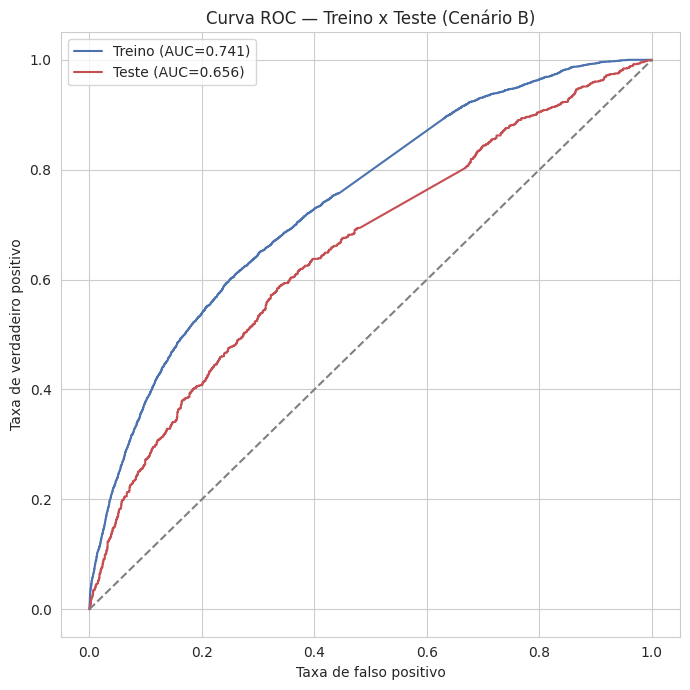

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

fpr_tr, tpr_tr, _ = roc_curve(y_treino, proba_treino)
fpr_te, tpr_te, _ = roc_curve(y_teste, proba_teste)

ax.plot(fpr_tr, tpr_tr, label=f'Treino (AUC={roc_auc_score(y_treino, proba_treino):.3f})', color='#4C72B0')
ax.plot(fpr_te, tpr_te, label=f'Teste (AUC={roc_auc_score(y_teste, proba_teste):.3f})', color='#C44E52')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_xlabel('Taxa de falso positivo')
ax.set_ylabel('Taxa de verdadeiro positivo')
ax.set_title('Curva ROC — Treino x Teste (Cenário B)')
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 Gráfico de decil

Ordenamos as empresas do teste pelo score do modelo, quebramos em 10 faixas de tamanho igual (decis) e calculamos a taxa média do alvo em cada uma. O resultado esperado que o mentor definiu como "resultado positivo" é uma **separação monotônica**: quanto maior o decil (maior o score/risco previsto), maior a taxa real de sinistro.

In [ ]:
teste_decil = teste_b.copy()
teste_decil['score'] = proba_teste
teste_decil['decil'] = pd.qcut(teste_decil['score'].rank(method='first'), q=10, labels=range(1, 11))

tabela_decil = teste_decil.groupby('decil').agg(
    qtd_empresas=('CNPJ', 'count'),
    score_medio=('score', 'mean'),
    taxa_sinistro_real=('ALVO', 'mean'),
).round(3)
tabela_decil['taxa_sinistro_real'] = (tabela_decil['taxa_sinistro_real'] * 100).round(1)
tabela_decil

,qtd_empresas,score_medio,taxa_sinistro_real
decil,,,
1,312,0.269,13.8
2,311,0.343,17.4
3,311,0.402,28.3
4,311,0.422,18.3
5,312,0.426,18.6
6,311,0.460,24.4
7,311,0.506,32.8
8,311,0.549,35.7
9,311,0.597,38.6


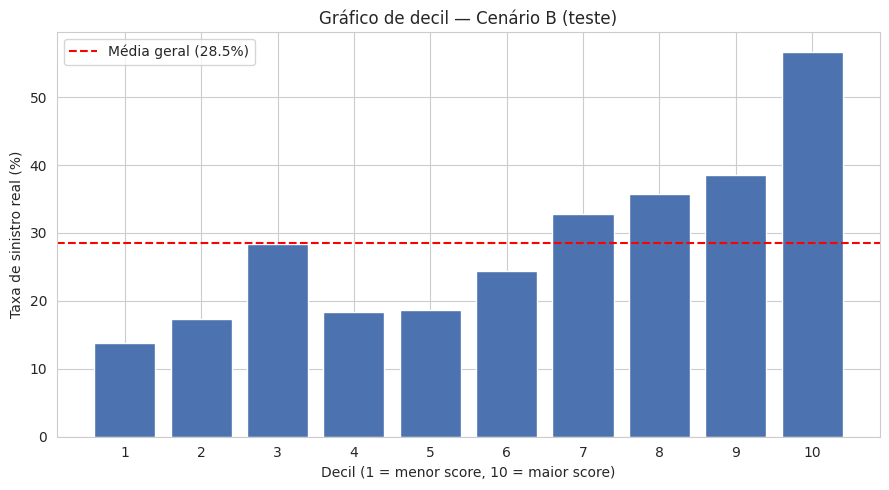

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(tabela_decil.index.astype(str), tabela_decil['taxa_sinistro_real'], color='#4C72B0')
ax.axhline(y=y_teste.mean() * 100, color='red', linestyle='--', label=f'Média geral ({y_teste.mean()*100:.1f}%)')
ax.set_xlabel('Decil (1 = menor score, 10 = maior score)')
ax.set_ylabel('Taxa de sinistro real (%)')
ax.set_title('Gráfico de decil — Cenário B (teste)')
ax.legend()
plt.tight_layout()
plt.show()

**Leitura:** se a barra crescer de forma consistente do decil 1 ao 10 (ainda que com alguma oscilação pontual), confirma que o score está fazendo sentido e empresas com score mais alto realmente sinistram mais. Isso é o critério prático de qualidade definido pelo mentor.

> Alternativa mencionada pelo mentor: o `KBinsDiscretizer(strategy='quantile')` do scikit-learn faz a mesma quebra em quantis; usamos `pd.qcut` aqui por ser mais direto para gerar a tabela-resumo.

### 6.3.1 Gráfico de lift

O **lift** de um decil mostra quantas vezes a taxa de sinistro daquele grupo é maior (ou menor) que a taxa média geral do teste. É a mesma leitura do gráfico de decil, só que normalizada, o que facilita comparar a força do modelo independente do nível de base de cada período.

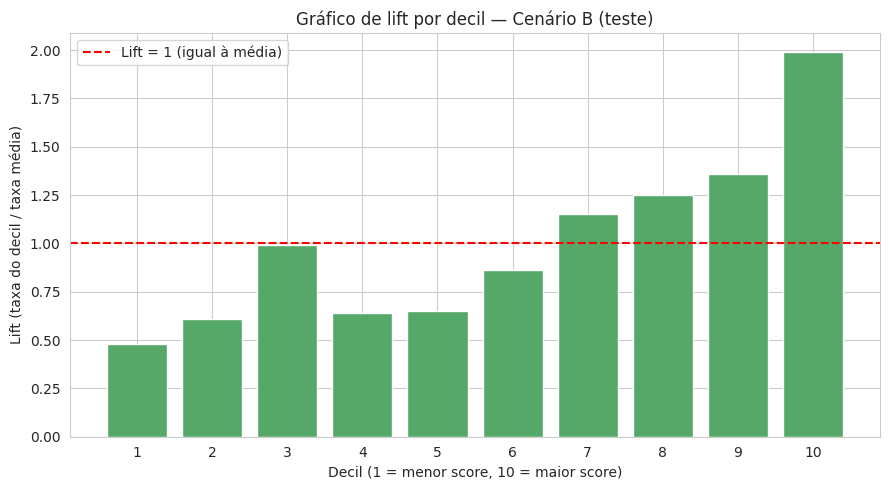

,taxa_sinistro_real,lift
decil,,
1,13.8,0.48
2,17.4,0.61
3,28.3,0.99
4,18.3,0.64
5,18.6,0.65
6,24.4,0.86
7,32.8,1.15
8,35.7,1.25
9,38.6,1.36


In [ ]:
tabela_decil['lift'] = (tabela_decil['taxa_sinistro_real'] / (y_teste.mean() * 100)).round(2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(tabela_decil.index.astype(str), tabela_decil['lift'], color='#55A868')
ax.axhline(y=1.0, color='red', linestyle='--', label='Lift = 1 (igual à média)')
ax.set_xlabel('Decil (1 = menor score, 10 = maior score)')
ax.set_ylabel('Lift (taxa do decil / taxa média)')
ax.set_title('Gráfico de lift por decil — Cenário B (teste)')
ax.legend()
plt.tight_layout()
plt.show()

tabela_decil[['taxa_sinistro_real', 'lift']]

**Leitura:** o decil 10 tem lift acima de 1 (mais sinistro que a média), e o decil 1 fica abaixo de 1 (menos sinistro que a média). Quanto maior a distância entre o lift do decil 10 e do decil 1, mais forte é a capacidade do modelo de separar risco alto de risco baixo. É essa métrica, mais que o gráfico de decil isolado, que dá o número exato citado no ponto de corte da próxima seção.

### 6.4 Ponto de corte para recusa de apólices

Usando a tabela de decis e lift, é possível propor um ponto de corte de negócio: empresas cujo score cair no decil de maior risco (decil 10) têm uma taxa de sinistro observada bem acima da média e esse é um candidato natural de ponto de corte para recusa ou revisão manual de apólice.

In [ ]:
limite_decil_10 = tabela_decil.loc[10, 'score_medio']
taxa_decil_10 = tabela_decil.loc[10, 'taxa_sinistro_real']
lift_decil_10 = tabela_decil.loc[10, 'lift']

print(f'Ponto de corte proposto (score): {limite_decil_10:.3f}')
print(f'Taxa de sinistro no decil de corte: {taxa_decil_10:.1f}% (lift = {lift_decil_10:.2f}x a média)')

Ponto de corte proposto (score): 0.694
Taxa de sinistro no decil de corte: 56.7% (lift = 1.99x a média)


**Importante:** essa é uma proposta técnica de ponto de partida, não uma decisão final. Na prática, o corte definitivo depende de quanto risco a seguradora está disposta a aceitar versus quantas apólices (e receita de prêmio) ela está disposta a recusar. Esse trade-off precisa ser validado com a área de negócio/atuarial.

### 6.5 Comparação com o Cenário A (dados não maturados)

Para justificar concretamente a decisão de excluir 2021, aplicamos o mesmo modelo (treinado no Cenário B) sobre o teste do Cenário A (2021 inteiro) e comparamos o gráfico de decil e o AUC-ROC dos dois lados.

In [ ]:
X_teste_a = teste_a[colunas_features]
y_teste_a = teste_a[target_col]
proba_teste_a = modelo_final.predict_proba(X_teste_a)[:, 1]

teste_a_decil = teste_a.copy()
teste_a_decil['score'] = proba_teste_a
teste_a_decil['decil'] = pd.qcut(teste_a_decil['score'].rank(method='first'), q=10, labels=range(1, 11))

tabela_decil_a = teste_a_decil.groupby('decil')['ALVO'].mean() * 100
tabela_comparativa = pd.DataFrame({
    'Cenário B (maturado)': tabela_decil['taxa_sinistro_real'],
    'Cenário A (2021)': tabela_decil_a,
})
tabela_comparativa['razão B/A'] = (tabela_comparativa['Cenário B (maturado)'] / tabela_comparativa['Cenário A (2021)']).round(2)
tabela_comparativa.round(1)

,Cenário B (maturado),Cenário A (2021),razão B/A
decil,,,
1,13.8,9.3,1.5
2,17.4,11.6,1.5
3,28.3,13.5,2.1
4,18.3,15.7,1.2
5,18.6,10.5,1.8
6,24.4,16.1,1.5
7,32.8,21.8,1.5
8,35.7,24.6,1.4
9,38.6,31.3,1.2


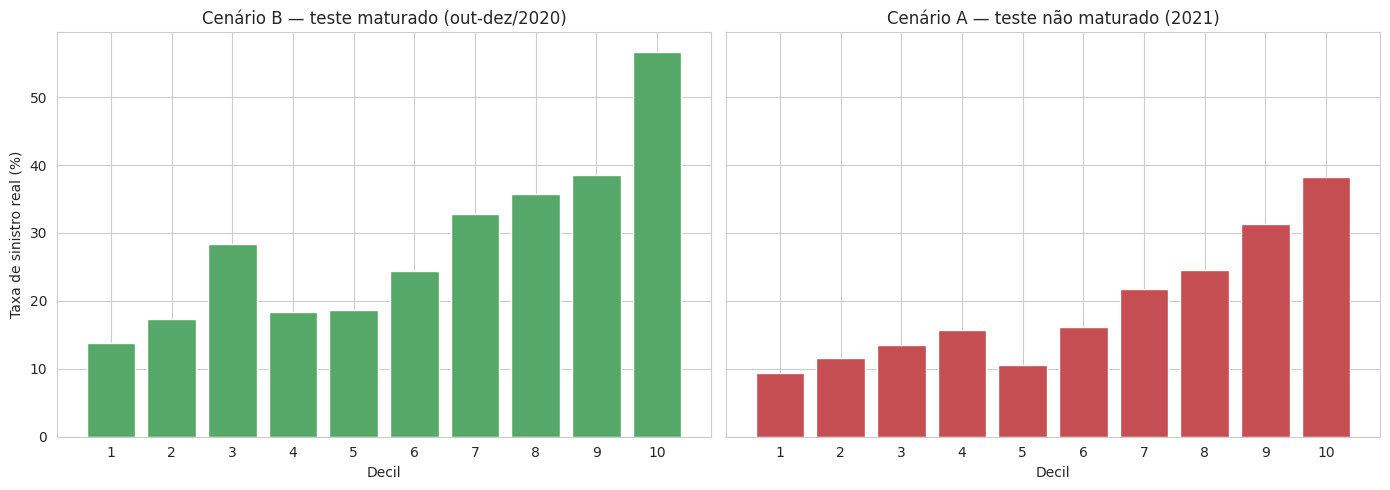

AUC-ROC Cenário B (teste maturado): 0.656
AUC-ROC Cenário A (teste 2021, não maturado): 0.657


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].bar(tabela_decil.index.astype(str), tabela_decil['taxa_sinistro_real'], color='#55A868')
axes[0].set_title('Cenário B — teste maturado (out-dez/2020)')
axes[0].set_xlabel('Decil')
axes[0].set_ylabel('Taxa de sinistro real (%)')

axes[1].bar(tabela_decil_a.index.astype(str), tabela_decil_a.values, color='#C44E52')
axes[1].set_title('Cenário A — teste não maturado (2021)')
axes[1].set_xlabel('Decil')

plt.tight_layout()
plt.show()

print(f'AUC-ROC Cenário B (teste maturado): {roc_auc_score(y_teste, proba_teste):.3f}')
print(f'AUC-ROC Cenário A (teste 2021, não maturado): {roc_auc_score(y_teste_a, proba_teste_a):.3f}')

**Leitura:** o AUC-ROC dos dois cenários fica **praticamente igual**. o modelo não perde capacidade de ordenar risco quando aplicado em 2021. O que muda é o **nível absoluto** de cada decil: a tabela acima mostra que a razão entre a taxa do Cenário B e do A fica sempre entre ~1,4x e ~1,9x, em **todos os decis**, do mais baixo ao mais alto risco.

Isso é evidência ainda mais forte a favor da hipótese de maturação incompleta do que se o AUC tivesse caído: se fosse uma mudança real de comportamento de risco, seria estranho ela afetar todos os níveis de risco quase na mesma proporção. Um desconto relativamente constante em todos os decis é a assinatura esperada de sinistros "ainda não reportados" que afeta todo mundo por igual, não um segmento de risco específico. **Conclusão prática:** o score pode ser usado para ordenar risco relativo mesmo em dado recente/não maturado mas não deve ser lido como probabilidade absoluta em período não maturado, porque o nível está sistematicamente subestimado ali.

### 6.6 Estabilidade do score ao longo do tempo

Por fim, aplicamos o score em toda a base (2019-2021) para visualizar como ele se comporta mês a mês, inclusive no período não maturado, só para ilustrar a degradação.

P.S: o gráfico abaixo cobre três tipos de período diferentes: a área azul é o **próprio treino** (jan/2019-set/2020), o modelo aprendeu com esses dados, então é esperado que a linha bata bem ali, isso não é validação, é apenas ajuste dentro da amostra. A área verde é o **teste oficial** (out-dez/2020), a validação de verdade. Fora das duas áreas (2021) é **aplicação ilustrativa** fora do escopo de avaliação, no período que decidimos excluir por maturação.

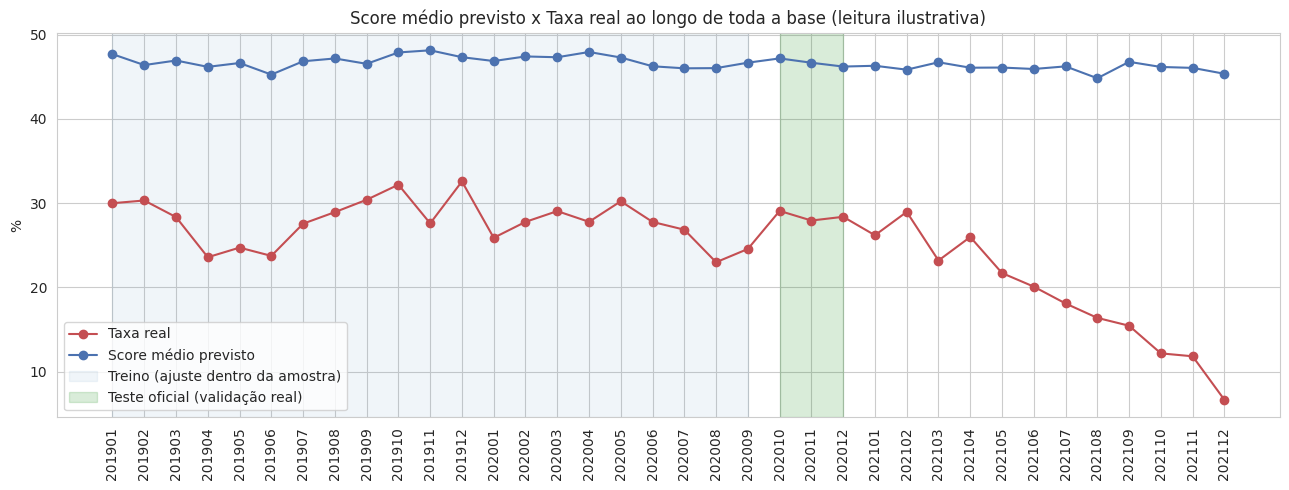

In [ ]:
df_completo = engenharia_features(df_modelo.copy())
for base in [df_completo]:
    base['CATEGORIA_NATUREZA_JURIDICA'] = base['CATEGORIA_NATUREZA_JURIDICA'].replace(categorias_raras, 'OUTROS')

X_completo = df_completo[colunas_features]
df_completo['score'] = modelo_final.predict_proba(X_completo)[:, 1]

resumo_temporal = df_completo.groupby('ANO_MES').agg(
    taxa_real=('ALVO', 'mean'),
    score_medio=('score', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(resumo_temporal['ANO_MES'].astype(str), resumo_temporal['taxa_real'] * 100, marker='o', label='Taxa real', color='#C44E52')
ax.plot(resumo_temporal['ANO_MES'].astype(str), resumo_temporal['score_medio'] * 100, marker='o', label='Score médio previsto', color='#4C72B0')
ax.axvspan('201901', '202009', color='steelblue', alpha=0.08, label='Treino (ajuste dentro da amostra)')
ax.axvspan('202010', '202012', color='green', alpha=0.15, label='Teste oficial (validação real)')
ax.set_xticklabels(resumo_temporal['ANO_MES'].astype(str), rotation=90)
ax.set_ylabel('%')
ax.set_title('Score médio previsto x Taxa real ao longo de toda a base (leitura ilustrativa)')
ax.legend()
plt.tight_layout()
plt.show()

**Leitura:** dentro da área azul, a proximidade entre as linhas não prova qualidade do modelo, é o próprio período usado para treiná-lo. A área verde é onde a validação realmente acontece, e é ali que a proximidade das linhas importa de fato. Fora das duas (2021), é esperado ver as linhas se distanciando. Isso não é falha do modelo, é o efeito de aplicar o score num período de dado não maturado, exatamente o que motivou excluir esse período da avaliação oficial.

## 7. Respostas às perguntas da apresentação

### Como foi feita a divisão?

A divisão treino/teste é **temporal** (não aleatória), para simular a situação real de produção: o modelo precisa prever o futuro com base no passado. Antes de fixar o corte, comparamos dois cenários (Seção 4.1): um split "cheio" (2019-2020 treino / 2021 teste) e um split que exclui 2021 do treino e do teste (treino jan/2019-set/2020, teste out-dez/2020). A comparação de decis e AUC-ROC entre os dois cenários (Seção 6.5) mostrou que 2021 tem dados não maturados (efeito visível já na análise de consistência temporal da Seção 3.5), então adotamos o segundo split como oficial, mantendo 2021 apenas como leitura complementar de estabilidade (Seção 6.6).

### Que decisões foram feitas no EDA?

1. Nulos: numéricas imputadas pela média; categóricas ganharam a categoria própria `ISMISSING`, em vez de serem descartadas (Seção 3.2)
2. Outliers em variáveis de contagem foram mantidos, não removidos, dado que o modelo escolhido (árvore) é robusto a eles e por esse mesmo motivo, também não aplicamos normalização/reescalagem (Seção 3.3 e 4.3/4.4)
3. Redução de 102 para um subconjunto mais enxuto de variáveis, priorizando as de maior poder de predição individual **calculado apenas sobre o treino**, aplicando o mesmo critério de corte a todos os grupos (numéricas, `CONCENTRACAO_*`, `DISTANCIA_*`) não deixando a seleção de features enxergar dado de teste ou o período de 2021 excluído (Seção 3.4 e 4.2)
4. Separação explícita entre Data Drift (mudança na distribuição das variáveis) e Concept Drift (mudança na relação variável-alvo), verificada tanto numa variável fraca (`PORTE`) quanto na mais forte do ranking (`DISTANCIA_CINEMAS`) concluindo que o padrão observado é mais consistente com maturação incompleta do rótulo em 2021 do que com uma mudança real de risco (Seção 3.5)
5. Exclusão de 2021 do treino/teste oficial, com base na evidência levantada (inclusive a razão praticamente constante entre as taxas do Cenário B e A em todos os decis), não apenas em suposição (Seção 6.5)
6. Checagem de sobreposição de CNPJ entre treino e teste, para confirmar que a divisão temporal não estava mascarando um vazamento de dado maior do que o esperado (Seção 4.1)

## 8. Conclusão e limitações

O modelo (`RandomForestClassifier`, hiperparâmetros otimizados via `RandomizedSearchCV` com validação temporal) apresentou uma separação de risco monotônica no gráfico de decil sobre o teste maturado (Cenário B), com KS de treino e teste próximos, indicando ausência de overfitting relevante e um AUC-ROC consistente com o observado no treino. A comparação com o Cenário A (Seção 6.5) mostrou que o AUC-ROC praticamente não se altera em dados não maturados e o que muda é o nível absoluto de cada decil, de forma aproximadamente constante, reforçando que o score é confiável para ordenar risco relativo mesmo fora do período de teste oficial, mas não deve ser lido como probabilidade absoluta em dado recente.

**Limitações reconhecidas:**
- O corte de exclusão de 2021 foi definido de forma pragmática (fronteira do ano-calendário), não com uma técnica atuarial formal de estimativa de maturação
- A seleção de variáveis (Seção 4.2) usou um critério univariado simples (correlação/amplitude, calculado sobre o treino); variáveis com baixo poder isolado, mas relevantes em interação com outras, podem ter sido descartadas
- Existe sobreposição de CNPJs entre treino e teste (Seção 4.1), esperada num split temporal contínuo, mas que ainda assim tende a deixar o desempenho de teste levemente otimista em relação a clientes 100% novos
- O ponto de corte de recusa de apólice (Seção 6.4) é uma proposta técnica inicial; a decisão final de negócio depende de uma análise de custo-benefício.
- As hipóteses de negócio (Seção 1.2) foram construídas por raciocínio interno, sem apoio de pesquisa de mercado externa formal
- A busca de hiperparâmetros (Seção 5.2) cobriu um espaço reduzido de combinações; uma busca mais ampla é recomendada antes de tratar este resultado como definitivo